# Robomimic Full Dataset Failure Recognition & Recovery Training
This notebook trains the `FailureRecognizer` on the complete robomimic dataset.
It splits the data into train/val sets, trains the model, and then evaluates
the recovery capabilities on unseen validation trajectories.

In [1]:
import os
import sys
import h5py
import torch
import numpy as np
import random
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML, display
import imageio

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.robomimic import RobomimicAdapter  
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.learning import FailureRecoveryDataset, FailureRecoveryTrainer
from a2l_pr.models import FailureRecognizer
from a2l_pr.config.config import ConfigManager

try:
    import robomimic.utils.obs_utils as ObsUtils
    import robomimic.utils.env_utils as EnvUtils
    import robomimic.utils.file_utils as FileUtils
    HAS_ROBOMIMIC = True
except ImportError:
    print("robomimic not found in environment, video rendering will be skipped.")
    HAS_ROBOMIMIC = False

I0000 00:00:1778173333.326352   10331 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778173333.664496   10331 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778173334.474602   10331 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Configuration & Dataset Iteration

In [2]:
robomimic_hdf5_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "robomimic", "robomimic", "datasets", "square", "ph", "low_dim_v15.hdf5"
))

config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)

LOW_DIM_OBS_KEYS = [
    "object",
    "robot0_eef_pos",
    "robot0_eef_quat",
    "robot0_gripper_qpos",
    "robot0_joint_pos",
    "robot0_joint_vel",
]
STATE_WINDOW = 12

def load_robomimic_trajectory(hdf5_path, demo_key="demo_0"):
    """Loads a single trajectory dictionary from a standard robomimic HDF5 file."""
    f = h5py.File(hdf5_path, 'r')
    demo_grp = f["data"][demo_key]
    obs_grp = demo_grp["obs"]

    trajectory = {
        'actions': demo_grp["actions"][:],
        'observations': {}
    }
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
    f.close()
    return trajectory

def _select_window_bounds(traj_len, center_idx, window_size):
    window_size = min(window_size, traj_len)
    half_window = window_size // 2
    start = max(0, int(center_idx) - half_window)
    end = min(traj_len, start + window_size)
    start = max(0, end - window_size)
    return start, end

def build_temporal_feature_vector(traj_dict, center_idx, window_size=STATE_WINDOW, obs_keys=None):
    actions = traj_dict['actions']
    obs = traj_dict['observations']
    traj_len = len(actions)
    if traj_len == 0:
        return np.zeros(1, dtype=np.float32)
    if obs_keys is None:
        obs_keys = LOW_DIM_OBS_KEYS
    start, end = _select_window_bounds(traj_len, center_idx, window_size)
    feature_rows = []
    for t in range(start, end):
        step_features = []
        for key in obs_keys:
            if key in obs:
                step_features.append(np.asarray(obs[key][t]).reshape(-1))
        step_features.append(np.asarray(actions[t]).reshape(-1))
        feature_rows.append(np.concatenate(step_features).astype(np.float32))
    if not feature_rows:
        return np.zeros(1, dtype=np.float32)
    return np.concatenate(feature_rows, axis=0).astype(np.float32)

def extract_learning_sample(
    traj_dict,
    failure_type_id,
    fsm_id=0,
    rec_params=None,
    center_idx=None,
    window_size=STATE_WINDOW,
    obs_keys=None,
 ):
    if rec_params is None:
        rec_params = np.zeros(7)

    actions = traj_dict['actions']
    if center_idx is None:
        center_idx = max(0, len(actions) - 1)

    features = build_temporal_feature_vector(
        traj_dict,
        center_idx=center_idx,
        window_size=window_size,
        obs_keys=obs_keys,
    )

    return {
        'frames': features,
        'failure_type_id': failure_type_id,
        'fsm_id': fsm_id,
        'recovery_params': rec_params.astype(np.float32),
    }

## 2. Build Dataset over All Trajectories

In [3]:
print(f"Loading dataset from: {robomimic_hdf5_path}")
f = h5py.File(robomimic_hdf5_path, 'r')
all_demos = list(f["data"].keys())
f.close()

# We might limit to a subset (e.g., 50 trajectories) to save time, or use all
# For a full test, let's use all_demos.
# Uncomment the line below to use a smaller subset if training takes too long.
# all_demos = all_demos[:50] 

random.seed(42)
random.shuffle(all_demos)
split_idx = int(0.8 * len(all_demos))
train_demos = all_demos[:split_idx]
val_demos = all_demos[split_idx:]

print(f"Total Demos: {len(all_demos)} | Train: {len(train_demos)} | Val: {len(val_demos)}")

adapter = RobomimicAdapter()
generator = PerturbationGenerator()

perturbation_types = [
    PerturbationType.UNDERREACH_IDLE,
    PerturbationType.PREMATURE_CLOSE,
    PerturbationType.LATERAL_DRIFT,
    PerturbationType.PREMATURE_OPEN
]

def _traj_length(traj_dict):
    return len(traj_dict['actions'])

def _normal_window_centers(traj_len, window_size):
    if traj_len <= 0:
        return []
    if traj_len <= window_size:
        return [max(0, traj_len - 1)]
    return [
        max(0, int(traj_len * 0.25)),
        max(0, int(traj_len * 0.50)),
        max(0, int(traj_len * 0.75)),
    ]

def generate_records_from_demos(demo_list, desc="Processing"):
    records = []
    vis_dict = None

    for demo_key in tqdm(demo_list, desc=desc):
        raw_traj = load_robomimic_trajectory(robomimic_hdf5_path, demo_key=demo_key)
        traj = adapter.load(raw_traj)
        traj_len = _traj_length(traj)

        # Inject config defaults
        dataset_defaults = config_mgr.get_dataset_defaults(traj['metadata'].get('dataset_type', 'ph'))
        traj['metadata'].update(dataset_defaults)
        traj['metadata'].update(config_mgr.get_perturbation_config())

        # Add several normal windows per trajectory so the model learns a temporal baseline,
        # not just a single end-of-trajectory snapshot.
        for center_idx in _normal_window_centers(traj_len, STATE_WINDOW):
            records.append(extract_learning_sample(
                traj,
                failure_type_id=0,
                center_idx=center_idx,
            ))

        # Save one validation trajectory for visualization later
        if vis_dict is None and desc == "Validation":
            vis_dict = {
                'demo_key': demo_key,
                'original': traj,
                'perturbations': {}
            }

        # Add perturbations with multiple windows around onset and sustained failure.
        for idx, p_type in enumerate(perturbation_types, start=1):
            res = generator.apply_perturbation(traj, p_type, severity=0.75)
            if res is None:
                continue

            rec_params = np.zeros(7)
            if p_type == PerturbationType.UNDERREACH_IDLE:
                rec_params[0] = 0.05
            elif p_type == PerturbationType.PREMATURE_CLOSE:
                rec_params[6] = -1.0
            elif p_type == PerturbationType.LATERAL_DRIFT:
                rec_params[1] = -0.05
            elif p_type == PerturbationType.PREMATURE_OPEN:
                rec_params[6] = 1.0

            perturb_start, perturb_end = res.perturbation_window
            pre_center = max(0, int(perturb_start) - STATE_WINDOW)
            onset_center = min(traj_len - 1, int(perturb_start) + max(1, STATE_WINDOW // 3))
            sustained_center = min(traj_len - 1, int(perturb_end))
            late_center = min(traj_len - 1, int(perturb_end) + max(1, STATE_WINDOW // 3))

            records.append(extract_learning_sample(
                traj,
                failure_type_id=0,
                center_idx=pre_center,
            ))
            records.append(extract_learning_sample(
                res.perturbed_trajectory,
                failure_type_id=idx,
                fsm_id=min(idx, 2),
                rec_params=rec_params,
                center_idx=onset_center,
            ))
            records.append(extract_learning_sample(
                res.perturbed_trajectory,
                failure_type_id=idx,
                fsm_id=min(idx, 2),
                rec_params=rec_params,
                center_idx=sustained_center,
            ))
            records.append(extract_learning_sample(
                res.perturbed_trajectory,
                failure_type_id=idx,
                fsm_id=min(idx, 2),
                rec_params=rec_params,
                center_idx=late_center,
            ))

            if vis_dict is not None and demo_key == vis_dict['demo_key']:
                vis_dict['perturbations'][p_type.name] = res.perturbed_trajectory

    return records, vis_dict

train_records, _ = generate_records_from_demos(train_demos, desc="Training")
val_records, vis_dict = generate_records_from_demos(val_demos, desc="Validation")

train_dataset = FailureRecoveryDataset(train_records)
val_dataset = FailureRecoveryDataset(val_records)

print(f"Train records: {len(train_records)} | Val records: {len(val_records)}")
class_counts = Counter(record['failure_type_id'] for record in train_records)
class_weights = [
    len(train_records) / (len(class_counts) * class_counts.get(class_id, 1))
    for class_id in range(len(perturbation_types) + 1)
 ]
print('Train class counts:', dict(class_counts))
print('Class weights:', class_weights)

Loading dataset from: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5
Total Demos: 200 | Train: 160 | Val: 40


Training:   0%|          | 0/160 [00:00<?, ?it/s]

Validation: 100%|██████████| 40/40 [00:00<00:00, 134.39it/s]

Train records: 3040 | Val records: 760
Train class counts: {0: 1120, 1: 480, 2: 480, 3: 480, 4: 480}
Class weights: [0.5428571428571428, 1.2666666666666666, 1.2666666666666666, 1.2666666666666666, 1.2666666666666666]


## 3. Train the Model

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

state_dim = int(train_dataset[0]['frames'].numel())
print(f"Temporal feature dimension: {state_dim}")

model = FailureRecognizer(
    num_frames=state_dim,
    action_dim=None,
    num_action_history=0,
    num_failure_types=len(perturbation_types) + 1,
    recovery_param_dim=7,
    num_fsm_templates=3,
    vision_encoder_type="mlp",
    hidden_dim=128
)

trainer = FailureRecoveryTrainer(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    label_smoothing=0.05,
    device=device,
    weights=class_weights
)

epochs = 25
best_val_loss = float('inf')

print("Starting Full Dataset Training...")
for epoch in range(1, epochs + 1):
    train_loss = trainer.train_epoch()
    val_metrics = trainer.evaluate()
    
    val_loss = val_metrics['val_loss']
    val_acc = val_metrics['val_failure_acc']
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_failure_recognizer.pth")

print("Training Complete! Best model saved.")

Using device: cuda
Temporal feature dimension: 528
Starting Full Dataset Training...


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1185.86it/s]


Epoch 1 | Train Loss: 3.0343 | Val Loss: 1.7082 | Val Acc: 61.32%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1691.00it/s]


Epoch 2 | Train Loss: 1.7531 | Val Loss: 1.2421 | Val Acc: 66.58%


...

Epoch 23 | Train Loss: 0.6373 | Val Loss: 0.9634 | Val Acc: 76.18%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1664.71it/s]


Epoch 24 | Train Loss: 0.6498 | Val Loss: 1.2106 | Val Acc: 73.82%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1711.18it/s]

Epoch 25 | Train Loss: 0.6445 | Val Loss: 1.1085 | Val Acc: 73.55%
Training Complete! Best model saved.


## 4. 3D Plot Visualization
Let's plot the spatial differences between the original trajectory and the generated failures.


--- 3D Trajectory Plots for demo_176 ---


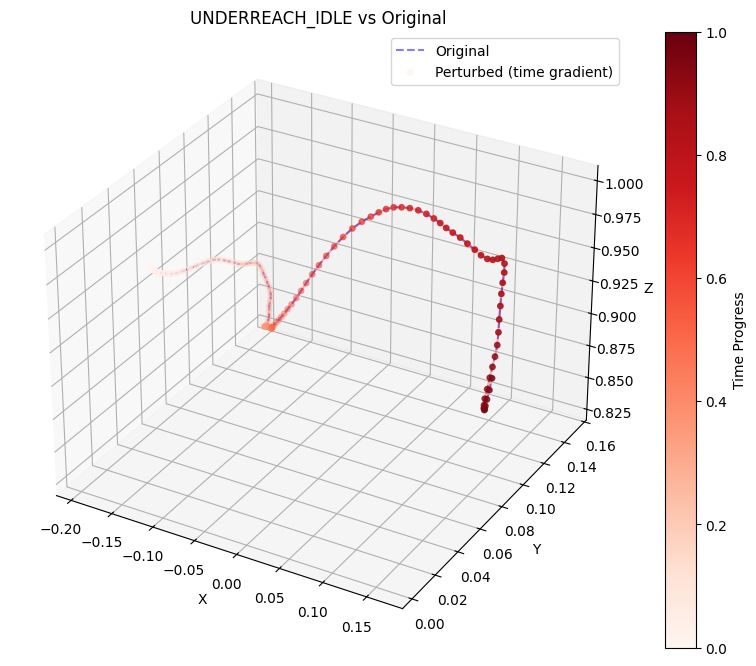

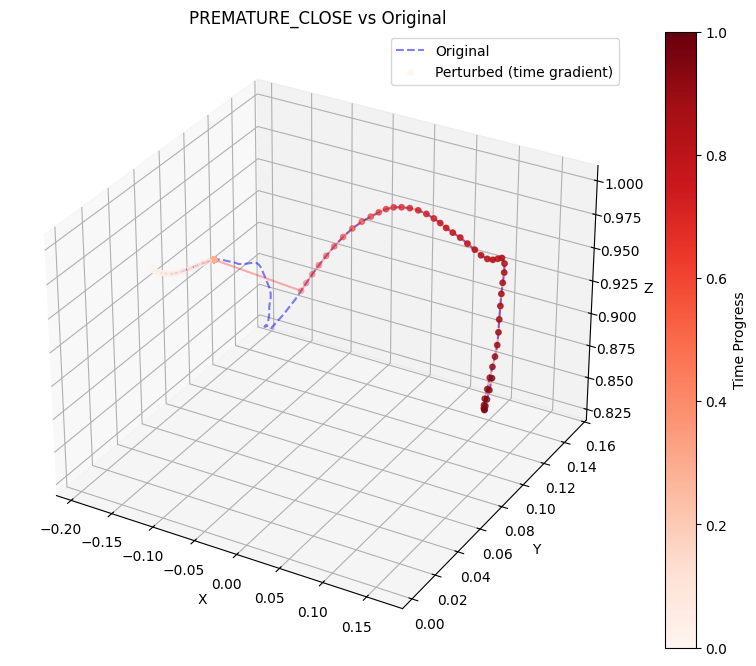

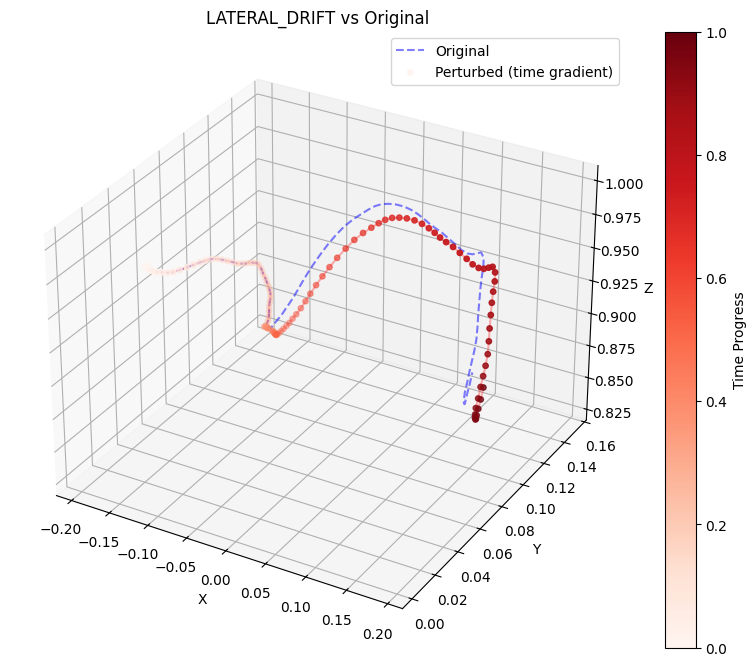

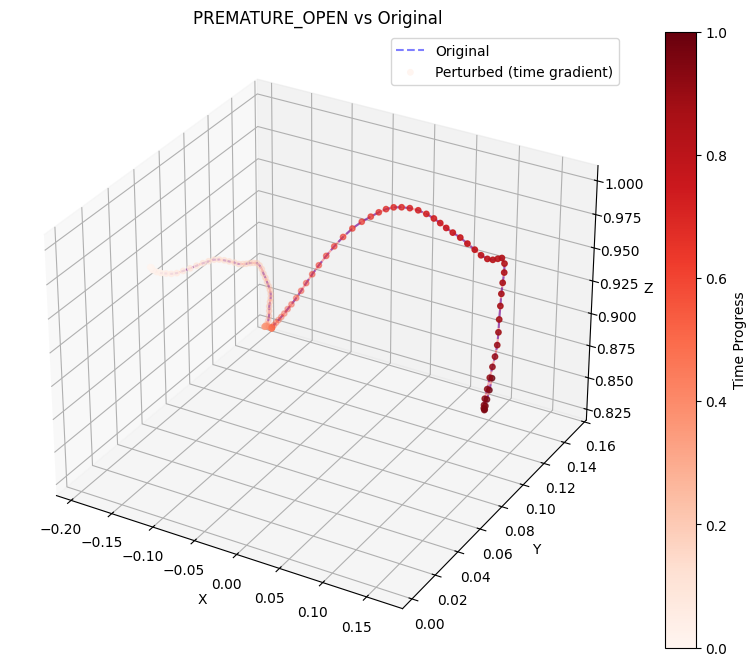

In [5]:
from a2l_pr.utils.trajectory import TrajectoryAnalyzer

def visualize_trajectory_comparison(original: dict, perturbed: dict, title: str):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    orig_pos = TrajectoryAnalyzer(original).get_ee_position()
    pert_pos = TrajectoryAnalyzer(perturbed).get_ee_position()
    
    if len(orig_pos) > 0:
        ax.plot(orig_pos[:, 0], orig_pos[:, 1], orig_pos[:, 2], 
                label='Original', color='blue', alpha=0.5, linestyle='--')
        
    if len(pert_pos) > 0:
        times = np.linspace(0, 1, len(pert_pos))
        sc = ax.scatter(pert_pos[:, 0], pert_pos[:, 1], pert_pos[:, 2], 
                   c=times, cmap='Reds', label='Perturbed (time gradient)', s=15)
        plt.colorbar(sc, label='Time Progress')
        ax.plot(pert_pos[:, 0], pert_pos[:, 1], pert_pos[:, 2], color='red', alpha=0.3)
        
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

if vis_dict is not None:
    print(f"\n--- 3D Trajectory Plots for {vis_dict['demo_key']} ---")
    orig_traj = vis_dict['original']
    for name, pert_traj in vis_dict['perturbations'].items():
        visualize_trajectory_comparison(orig_traj, pert_traj, f"{name} vs Original")

## 5. Simulation Visualization of Recovery
We take the `vis_dict` saved from the validation set (unseen during training)
and use the trained model to predict recovery, then simulate it.

In [6]:
if HAS_ROBOMIMIC and vis_dict is not None:
    print("\n--- Generating Recovery Simulation Videos on Validation Trajectory ---")
    
    # Load best model
    model.load_state_dict(torch.load("best_failure_recognizer.pth", map_location=device))
    model.eval()

    def render_trajectory_to_video(traj_dict, dataset_path, ep_name, output_path):
        if not os.path.exists(dataset_path): return False
        try:
            dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
            ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
            env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
            env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)
            
            with h5py.File(dataset_path, 'r') as f:
                states = f[ep_name]['states'][()]
                initial_state = dict(states=states[0])
                if EnvUtils.is_robosuite_env(env_meta):
                    initial_state["model"] = f[ep_name].attrs["model_file"]
                    
            env.reset_to(initial_state)
            actions = traj_dict.get('actions', [])
            
            writer = imageio.get_writer(output_path, fps=20)
            for i in range(len(actions)):
                env.step(actions[i])
                if i % 5 == 0:
                    frame = env.render(mode="rgb_array", height=256, width=256, camera_name="agentview")
                    writer.append_data(frame)
            writer.close()
            return True
        except Exception as e:
            print(f"Render failed: {e}")
            return False

    OUTPUT_DIR = Path(os.getcwd()) / "output"
    OUTPUT_DIR.mkdir(exist_ok=True)
    # The keys in vis_dict are like 'demo_176', but HDF5 needs 'data/demo_176'
    ep_name = f"data/{vis_dict['demo_key']}"
    
    html_content = f"<h2>Validation Test: {ep_name}</h2><div style='display: flex; flex-direction: row; flex-wrap: wrap; justify-content: space-around;'>"
    
    for name, perturbed_traj in vis_dict['perturbations'].items():
        # Predict recovery using the same temporal state-vector input used for training.
        sample = extract_learning_sample(
            perturbed_traj,
            failure_type_id=0,
            center_idx=max(0, len(perturbed_traj['actions']) - 1),
        )
        frames_tensor = torch.tensor(sample['frames']).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(frames_tensor)
            pred_rec_params = outputs['recovery_params'][0].cpu().numpy()
            pred_failure_idx = torch.argmax(outputs['failure_logits'], dim=1).item()
        
        print(f"Evaluating {name}...")
        print(f" -> Predicted Failure Class: {pred_failure_idx} (Target > 0)")
        print(f" -> Predicted Recovery Params: {np.round(pred_rec_params, 3)}")
        
        recovered_actions = list(perturbed_traj.get('actions', []))
        
        # If it correctly recognized a failure, simulate the recovery
        # To make it visible, we execute the predicted delta parameters repeatedly.
        # If the model learned well, pred_rec_params should match the targets
        # we defined (e.g. +/- 0.05 for movement, +/- 1.0 for gripper).
        if pred_failure_idx != 0:
            for _ in range(30): # Add 30 steps of the recovery residual
                # Apply a clip/scaling if necessary to keep simulation stable
                stable_recovery = np.clip(pred_rec_params, -1.0, 1.0)
                recovered_actions.append(stable_recovery)
                
        recovered_traj_dict = {'actions': recovered_actions}
        
        # Render Failure
        fail_out = str(OUTPUT_DIR / f'full_train_{name}_failure.mp4')
        if render_trajectory_to_video(perturbed_traj, robomimic_hdf5_path, ep_name, fail_out):
            fail_b64 = b64encode(open(fail_out, "rb").read()).decode('ascii')
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px;'>
                <h3>Failure: {name}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{fail_b64}' type='video/mp4'>
                </video>
            </div>
            """
            
        # Render Recovery
        rec_out = str(OUTPUT_DIR / f'full_train_{name}_recovery.mp4')
        if render_trajectory_to_video(recovered_traj_dict, robomimic_hdf5_path, ep_name, rec_out):
            rec_b64 = b64encode(open(rec_out, "rb").read()).decode('ascii')
            
            border_color = "green" if pred_failure_idx != 0 else "red"
            title = "Recovery (Success)" if pred_failure_idx != 0 else "Recovery (Failed to Detect)"
            
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px; border: 2px solid {border_color};'>
                <h3>{title}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{rec_b64}' type='video/mp4'>
                </video>
            </div>
            """

    html_content += "</div>"
    display(HTML(html_content))
    print("\nVisualization Generation Complete!")

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)



--- Generating Recovery Simulation Videos on Validation Trajectory ---
Evaluating UNDERREACH_IDLE...
 -> Predicted Failure Class: 1 (Target > 0)
 -> Predicted Recovery Params: [ 0.044 -0.005  0.003 -0.006  0.01   0.013 -0.016]

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []


[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Created environment with name NutAssemblySquare
Action size is 7



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Evaluating PREMATURE_CLOSE...
 -> Predicted Failure Class: 1 (Target > 0)
 -> Predicted Recovery Params: [ 0.044 -0.005  0.003 -0.006  0.01   0.013 -0.016]

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Evaluating LATERAL_DRIFT...
 -> Predicted Failure Class: 1 (Target > 0)
 -> Predicted Recovery Params: [ 0.044 -0.005  0.003 -0.006  0.01  


Visualization Generation Complete!


## Experiment Block: MLP vs GRU

The cells below run two quick comparisons on the existing low-dimensional robomimic split:

- a temporal MLP baseline using the current flattened feature windows
- a GRU variant that reshapes those same windows back into sequences

Both use the same train/validation split and the same perturbation records so the comparison stays local and reproducible.

In [7]:
import math
import importlib
from torch.utils.data import Dataset, DataLoader

import a2l_pr.learning.trainer as trainer_module
trainer_module = importlib.reload(trainer_module)
FailureRecoveryTrainer = trainer_module.FailureRecoveryTrainer

EXPERIMENT_EPOCHS = 6
EXPERIMENT_LR = 3e-4
EXPERIMENT_WEIGHT_DECAY = 1e-4
EXPERIMENT_GRAD_CLIP = 1.0
EXPERIMENT_LABEL_SMOOTHING = 0.05
EXPERIMENT_BATCH_SIZE = 32

sample_frames = train_dataset[0]['frames']
if sample_frames.ndim == 4:
    sequence_window_size = sample_frames.shape[0]
    sequence_feature_dim = int(sample_frames[0].numel())
elif sample_frames.ndim == 1:
    sequence_window_size = 12
    sequence_feature_dim = int(sample_frames.numel() // sequence_window_size)
    assert sequence_feature_dim * sequence_window_size == int(sample_frames.numel()), (
        'The current temporal window is not evenly divisible into per-step features.'
    )
else:
    sequence_window_size = sample_frames.shape[0]
    sequence_feature_dim = int(sample_frames.reshape(sequence_window_size, -1).shape[-1])

class SequenceFailureRecoveryDataset(Dataset):
    def __init__(self, records, window_size):
        self.records = records
        self.window_size = window_size

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        frames = record['frames']
        if isinstance(frames, np.ndarray):
            frames = torch.from_numpy(frames).float()
        if frames.ndim == 1:
            step_dim = frames.numel() // self.window_size
            frames = frames.reshape(self.window_size, step_dim)
        elif frames.ndim >= 2:
            frames = frames.reshape(frames.shape[0], -1)

        failure_type = torch.tensor(record['failure_type_id'], dtype=torch.long)
        fsm_id = torch.tensor(record.get('fsm_id', 0), dtype=torch.long)
        rec_params = torch.tensor(record.get('recovery_params', np.zeros(7)), dtype=torch.float32)

        return {
            'frames': frames,
            'failure_type': failure_type,
            'fsm_id': fsm_id,
            'recovery_params': rec_params,
        }

class GRUFailureRecognizer(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_failure_types, recovery_param_dim, num_fsm_templates):
        super().__init__()
        self.gru = torch.nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.shared = torch.nn.Sequential(
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.Dropout(0.15),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.15),
        )
        self.failure_head = torch.nn.Linear(hidden_dim, num_failure_types)
        self.recovery_head = torch.nn.Linear(hidden_dim, recovery_param_dim)
        self.fsm_head = torch.nn.Linear(hidden_dim, num_fsm_templates)

    def forward(self, frames, actions=None):
        if frames.ndim == 2:
            frames = frames.unsqueeze(1)
        _, hidden = self.gru(frames)
        features = self.shared(hidden[-1])
        return {
            'failure_logits': self.failure_head(features),
            'recovery_params': self.recovery_head(features),
            'fsm_logits': self.fsm_head(features),
        }


def run_experiment(model, train_ds, val_ds, label, epochs=EXPERIMENT_EPOCHS, batch_size=EXPERIMENT_BATCH_SIZE):
    trainer = FailureRecoveryTrainer(
        model=model,
        train_dataset=train_ds,
        val_dataset=val_ds,
        batch_size=batch_size,
        lr=EXPERIMENT_LR,
        weight_decay=EXPERIMENT_WEIGHT_DECAY,
        grad_clip=EXPERIMENT_GRAD_CLIP,
        label_smoothing=EXPERIMENT_LABEL_SMOOTHING,
        device=device,
        weights=class_weights,
    )

    history = []
    best_val = float('inf')
    print(f'\n=== {label} ===')
    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_epoch()
        val_metrics = trainer.evaluate()
        val_loss = val_metrics['val_loss']
        val_acc = val_metrics['val_failure_acc'] * 100.0
        best_val = min(best_val, val_loss)
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
        })
        print(
            f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%'
        )

    return trainer, history, best_val

print(f'Sequence feature dim: {sequence_feature_dim} | Window size: {sequence_window_size}')

Sequence feature dim: 44 | Window size: 12


In [8]:
torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

class TemporalMLPRecognizer(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_failure_types, recovery_param_dim, num_fsm_templates):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.15),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.15),
        )
        self.failure_head = torch.nn.Linear(hidden_dim, num_failure_types)
        self.recovery_head = torch.nn.Linear(hidden_dim, recovery_param_dim)
        self.fsm_head = torch.nn.Linear(hidden_dim, num_fsm_templates)

    def forward(self, frames, actions=None):
        if frames.ndim > 2:
            frames = frames.reshape(frames.shape[0], -1)
        elif frames.ndim == 1:
            frames = frames.unsqueeze(0)
        features = self.encoder(frames)
        return {
            'failure_logits': self.failure_head(features),
            'recovery_params': self.recovery_head(features),
            'fsm_logits': self.fsm_head(features),
        }

mlp_experiment_model = TemporalMLPRecognizer(
    input_dim=int(train_dataset[0]['frames'].numel()),
    hidden_dim=128,
    num_failure_types=len(perturbation_types) + 1,
    recovery_param_dim=7,
    num_fsm_templates=3,
)

sequence_train_dataset = SequenceFailureRecoveryDataset(train_records, sequence_window_size)
sequence_val_dataset = SequenceFailureRecoveryDataset(val_records, sequence_window_size)
sequence_input_dim = int(sequence_train_dataset[0]['frames'].shape[-1])

gru_experiment_model = GRUFailureRecognizer(
    input_dim=sequence_input_dim,
    hidden_dim=128,
    num_failure_types=len(perturbation_types) + 1,
    recovery_param_dim=7,
    num_fsm_templates=3,
)

mlp_trainer, mlp_history, mlp_best_val = run_experiment(
    mlp_experiment_model,
    train_dataset,
    val_dataset,
    label='Temporal MLP Baseline',
)

gru_trainer, gru_history, gru_best_val = run_experiment(
    gru_experiment_model,
    sequence_train_dataset,
    sequence_val_dataset,
    label='GRU Temporal Model',
)

comparison_rows = [
    {
        'model': 'temporal_mlp',
        'best_val_loss': mlp_best_val,
        'final_train_loss': mlp_history[-1]['train_loss'],
        'final_val_loss': mlp_history[-1]['val_loss'],
        'final_val_acc': mlp_history[-1]['val_acc'],
    },
    {
        'model': 'gru_temporal',
        'best_val_loss': gru_best_val,
        'final_train_loss': gru_history[-1]['train_loss'],
        'final_val_loss': gru_history[-1]['val_loss'],
        'final_val_acc': gru_history[-1]['val_acc'],
    },
]

print('\n=== Comparison Summary ===')
for row in comparison_rows:
    print(
        f"{row['model']}: best_val_loss={row['best_val_loss']:.4f}, "
        f"final_train_loss={row['final_train_loss']:.4f}, "
        f"final_val_loss={row['final_val_loss']:.4f}, "
        f"final_val_acc={row['final_val_acc']:.2f}%"
    )


=== Temporal MLP Baseline ===


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1765.40it/s]


Epoch 01 | Train Loss: 2.7013 | Val Loss: 2.0462 | Val Acc: 57.63%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1754.08it/s]


Epoch 02 | Train Loss: 1.8413 | Val Loss: 1.5737 | Val Acc: 57.24%


...

Epoch 04 | Train Loss: 1.3694 | Val Loss: 1.3568 | Val Acc: 66.45%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1517.57it/s]


Epoch 05 | Train Loss: 1.2155 | Val Loss: 1.2451 | Val Acc: 69.34%


Evaluating: 100%|██████████| 24/24 [00:00<00:00, 1486.68it/s]

Epoch 06 | Train Loss: 1.1213 | Val Loss: 1.1992 | Val Acc: 71.18%

=== Comparison Summary ===
temporal_mlp: best_val_loss=1.1097, final_train_loss=1.0436, final_val_loss=1.1097, final_val_acc=71.71%
gru_temporal: best_val_loss=1.1992, final_train_loss=1.1213, final_val_loss=1.1992, final_val_acc=71.18%
